In [1]:
# Figure 4: robustness. Does the headline result survive scrutiny, rather than
# depending on one metric, one baseline choice, or one confirming dataset? Three
# checks from Analysis D (Day 7 / Gate 2), re-derived independently here rather
# than read from a stored intermediate: an expression-matched annotation-depth
# control, isp-1 cross-mutant concordance, and the raw-count magnitude behind the
# top-ranked genes (where a fold-change reading would silently break). The full
# metric-sensitivity scatter (Score vs Score/variability, all 61 genes) is Figure
# S2, not repeated here.
import os
if os.path.basename(os.getcwd()) == "scripts":
    os.chdir("..")
import sys
sys.path.insert(0, "scripts")

import gzip
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binomtest
from figure_style import BLUE, ORANGE, GREEN, GREY, INK, FULL_W, panel_label, save

soo = pd.read_excel("data/raw/ATFS1_targets_Soo.xlsx", sheet_name="Sheet1")
soo = soo.iloc[0:64].dropna(subset=["Gene name"]).rename(columns={
    "Gene sequence \nname": "seqname",
    "Significantly upregulated in isp-1 worms": "isp1_up",
})
regulon = soo[~soo["Gene name"].isin(["hsp-6", "hsp-60"])].reset_index(drop=True)
if len(regulon) != 61:
    raise RuntimeError(f"Expected 61 regulon genes, got {len(regulon)}.")
regulon["rank_score"] = regulon["Score"].rank(ascending=False, method="min").astype(int)
regulon["rank_var"] = regulon["Score/variability"].rank(ascending=False, method="min").astype(int)

ids = pd.read_csv("ref_data/c_elegans.PRJNA13758.WS285.geneIDs.txt.gz", header=None,
                  names=["taxon", "gid", "public_name", "seqname", "status", "biotype"])
seq_to_gid = {str(s).lower(): g for s, g in zip(ids["seqname"], ids["gid"]) if pd.notna(s)}
regulon["gid"] = regulon["seqname"].str.lower().map(seq_to_gid)
print(f"Regulon: {len(regulon)} genes, {regulon['gid'].isna().sum()} unmapped")

Regulon: 61 genes, 0 unmapped


In [2]:
# Raw CPM and the replicate-group mapping (same as analysis_d.ipynb, re-derived
# and re-validated against the recorded group sizes before use).
CPM_RAW = "ref_data/GSE110984/GSE110984_raw_CPM_table_VANJ_20171130.txt.gz"
cpm = pd.read_csv(CPM_RAW, sep="\t")

GROUPS = {
    "WT": ["WT1","WT2","WT3","WT_4","WT_5","WT_6","WT_7","WT_8","WT_9","WTb","WTbl","WTr"],
    "atfs-1(gk3094)": ["atfs1DEL1","atfs1DEL2","atfs1DEL3","atfs1b","atfs1bl","atfs1r"],
    "nuo-6": ["nuo6_1","nuo6_2","nuo6_3","nuo6_4","nuo6_5","nuo6_6"],
    "nuo-6;atfs-1": ["NA238b","NA238bl","NA238r"],
    "et15": ["atfs1et152","atfs1et153","atfs1et154","atfs1et155","atfs1et156"],
    "et17": ["atfs1et171","atfs1et172","atfs1et173","atfs1et174","atfs1et175","atfs1et176"],
}
expected_sizes = {"WT": 12, "atfs-1(gk3094)": 6, "nuo-6": 6, "nuo-6;atfs-1": 3, "et15": 5, "et17": 6}
if {k: len(v) for k, v in GROUPS.items()} != expected_sizes:
    raise RuntimeError("Replicate group sizes don't match the recorded counts.")

top10_var = set(regulon.nsmallest(10, "rank_var")["Gene name"])
top10_score = set(regulon.nsmallest(10, "rank_score")["Gene name"])
top_genes = regulon[regulon["Gene name"].isin(top10_var | top10_score)].copy()

cpm_by_gid = cpm.set_index("ens_gene")
rows = []
for _, g in top_genes.iterrows():
    r = cpm_by_gid.loc[g["gid"]]
    wt_vals = r[GROUPS["WT"]].values.astype(float)
    rows.append({
        "gene": g["Gene name"], "rank_var": g["rank_var"],
        "wt_mean": wt_vals.mean(), "wt_zero_of_12": int((wt_vals == 0).sum()),
        "nuo6_mean": r[GROUPS["nuo-6"]].values.astype(float).mean(),
        "et15_mean": r[GROUPS["et15"]].values.astype(float).mean(),
        "et17_mean": r[GROUPS["et17"]].values.astype(float).mean(),
    })
magnitude = pd.DataFrame(rows).sort_values("rank_var").reset_index(drop=True)

EXPECTED_ZERO_GENE = {"F22B3.7": 9}
near_zero = magnitude[magnitude["wt_zero_of_12"] >= 6].set_index("gene")["wt_zero_of_12"].to_dict()
if near_zero != EXPECTED_ZERO_GENE:
    raise RuntimeError(f"Near-zero WT baseline genes changed: got {near_zero}, expected {EXPECTED_ZERO_GENE}.")
print(f"Magnitude panel: {len(magnitude)} genes, near-zero WT baseline validated "
      f"(F22B3.7, {near_zero['F22B3.7']} of 12 reps zero).")

Magnitude panel: 17 genes, near-zero WT baseline validated (F22B3.7, 9 of 12 reps zero).


In [3]:
# isp-1 concordance - a citation check against Soo's own column, not a
# re-derivation from raw isp-1 data.
n_up = int((regulon["isp1_up"].astype(str).str.strip().str.lower() == "yes").sum())
exceptions = regulon[regulon["isp1_up"].astype(str).str.strip().str.lower() != "yes"]
EXPECTED_EXCEPTIONS = {"F49H12.4", "Y51B9A.9", "H34I24.2", "tag-234"}
if n_up != 57 or set(exceptions["Gene name"]) != EXPECTED_EXCEPTIONS:
    raise RuntimeError("isp-1 concordance does not match the recorded 57/61 figure.")
print(f"isp-1 concordance validated: {n_up} of 61, exceptions {sorted(exceptions['Gene name'])}")

isp-1 concordance validated: 57 of 61, exceptions ['F49H12.4', 'H34I24.2', 'Y51B9A.9', 'tag-234']


In [4]:
# Annotation-depth control: does the regulon's unannotated fraction reflect
# ATFS-1 targeting, or just that it skews toward lowly-expressed, poorly-curated
# genes? Matched by expression decile against all expressed genes, same method as
# analysis_d.ipynb, re-derived here.
OBO, GAF = "ref_data/go/go-basic.obo", "ref_data/go/wb.gaf.gz"
terms, alt_id_map, cur = {}, {}, None
with open(OBO) as fh:
    for line in fh:
        line = line.rstrip("\n")
        if line.startswith("["):
            if cur and cur["id"]:
                terms[cur["id"]] = cur
            cur = {"id": None, "obsolete": False} if line == "[Term]" else None
            continue
        if cur is None or not line:
            continue
        key, _, val = line.partition(": ")
        if key == "id":
            cur["id"] = val
        elif key == "alt_id":
            alt_id_map[val] = cur["id"]
        elif key == "is_obsolete" and val == "true":
            cur["obsolete"] = True
if cur and cur["id"]:
    terms[cur["id"]] = cur

annotated_genes = set()
with gzip.open(GAF, "rt") as fh:
    for line in fh:
        if line.startswith("!"):
            continue
        f = line.rstrip("\n").split("\t")
        if len(f) < 15 or f[12] != "taxon:6239" or f[3].startswith("NOT") or f[6] == "ND":
            continue
        go_id = alt_id_map.get(f[4], f[4])
        if go_id in terms and not terms[go_id]["obsolete"]:
            annotated_genes.add(f[1])

expressed = pd.read_csv(
    "ref_data/GSE110984/GSE110984_normalized_filtered_CPM_table_VANJ_20171130.txt.gz", sep="\t"
)[["ens_gene"]].dropna()
expr_mean = cpm.set_index("ens_gene")[GROUPS["WT"]].mean(axis=1)
expressed["mean_wt_cpm"] = expressed["ens_gene"].map(expr_mean)
expressed = expressed.dropna(subset=["mean_wt_cpm"])
expressed["annotated"] = expressed["ens_gene"].isin(annotated_genes)
expressed["decile"] = pd.qcut(expressed["mean_wt_cpm"], 10, labels=False, duplicates="drop")
decile_rate = expressed.groupby("decile")["annotated"].mean()

regulon_expr = regulon.dropna(subset=["gid"]).copy()
regulon_expr["mean_wt_cpm"] = regulon_expr["gid"].map(expr_mean)
regulon_expr = regulon_expr.dropna(subset=["mean_wt_cpm"])
regulon_expr["decile"] = pd.cut(
    regulon_expr["mean_wt_cpm"],
    bins=pd.qcut(expressed["mean_wt_cpm"], 10, retbins=True, duplicates="drop")[1],
    labels=False, include_lowest=True,
)
expected_rate = regulon_expr["decile"].map(decile_rate).mean()
regulon_expr["annotated"] = regulon_expr["gid"].isin(annotated_genes)
observed_rate = regulon_expr["annotated"].mean()
n_annotated_obs = int(regulon_expr["annotated"].sum())
test = binomtest(n_annotated_obs, len(regulon_expr), expected_rate)

if round(100 * observed_rate, 1) != 68.9 or round(100 * expected_rate, 1) != 61.5 or round(test.pvalue, 3) != 0.292:
    raise RuntimeError(
        f"Annotation-depth control changed: observed={observed_rate:.3f}, "
        f"expected={expected_rate:.3f}, p={test.pvalue:.3f} - does not match the recorded values.")
print(f"Annotation-depth control validated: observed {observed_rate:.1%}, "
      f"expected {expected_rate:.1%}, p={test.pvalue:.3f}.")

Annotation-depth control validated: observed 68.9%, expected 61.5%, p=0.292.


Saved figures/figure4_robustness.{pdf,svg,png}


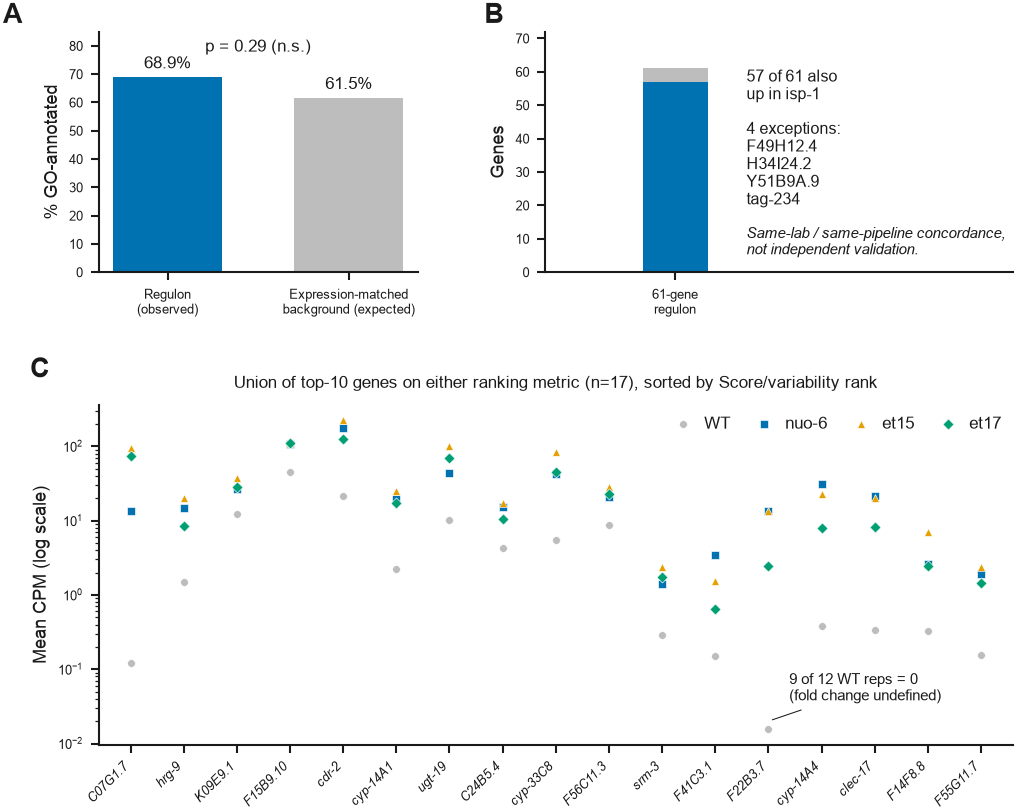

In [5]:
# Draw. A: annotation-depth control. B: isp-1 concordance. C: raw-count magnitude
# for the union-top-10 genes on either metric, flagging the one whose WT baseline
# is too close to zero for a fold-change reading to mean anything.
fig = plt.figure(figsize=(FULL_W, FULL_W * 0.78))
axA = fig.add_axes([0.08, 0.66, 0.30, 0.29])
axB = fig.add_axes([0.50, 0.66, 0.44, 0.29])
axC = fig.add_axes([0.08, 0.09, 0.86, 0.41])

# Panel A
bars = axA.bar([0, 1], [100 * observed_rate, 100 * expected_rate],
               color=[BLUE, GREY], width=0.6)
axA.set_xticks([0, 1])
axA.set_xticklabels(["Regulon\n(observed)", "Expression-matched\nbackground (expected)"], fontsize=8)
axA.set_ylabel("% GO-annotated", fontsize=8.5)
axA.set_ylim(0, 85)
for b, v in zip(bars, [observed_rate, expected_rate]):
    axA.text(b.get_x() + b.get_width() / 2, 100 * v + 2, f"{100*v:.1f}%",
              ha="center", va="bottom", fontsize=8, color=INK)
axA.text(0.5, 78, f"p = {test.pvalue:.2f} (n.s.)", ha="center", fontsize=8, color=INK,
          transform=axA.transData)
axA.tick_params(labelsize=6)
for spine in ("top", "right"):
    axA.spines[spine].set_visible(False)
panel_label(axA, "A", dx=-0.30, dy=1.12)

# Panel B. Two text blocks in a first draft (the caption above the bar, the
# exceptions list beside it) collided in the same empty region regardless of small
# offset adjustments - caught only by inspecting the rendered PNG twice, not by the
# code running cleanly either time. Fixed by merging into one text block, placed
# once, well clear of both the bar and the caption.
axB.bar([0], [n_up], color=BLUE, width=0.5)
axB.bar([0], [61 - n_up], bottom=[n_up], color=GREY, width=0.5)
axB.set_xlim(-1, 2.6)
axB.set_ylim(0, 72)
axB.set_xticks([0])
axB.set_xticklabels(["61-gene\nregulon"], fontsize=8)
axB.set_ylabel("Genes", fontsize=8.5)
# Both text blocks sit inside the plot area to the right of the bar. Set above the
# axes, the caption ran into the y-axis tick labels once the base font size went up.
summary = (f"{n_up} of 61 also\nup in isp-1\n\n4 exceptions:\n" +
           "\n".join(sorted(EXPECTED_EXCEPTIONS)))
axB.text(0.55, 40, summary, fontsize=7.5, va="center", ha="left", color=INK)
axB.text(0.55, 9, "Same-lab / same-pipeline concordance,\nnot independent validation.",
         fontsize=7, style="italic", color=INK, ha="left", va="center")
axB.tick_params(labelsize=6)
for spine in ("top", "right"):
    axB.spines[spine].set_visible(False)
panel_label(axB, "B", dx=-0.13, dy=1.12)

# Panel C
xg = np.arange(len(magnitude))
series = [("WT", "wt_mean", GREY, "o"), ("nuo-6", "nuo6_mean", BLUE, "s"),
          ("et15", "et15_mean", ORANGE, "^"), ("et17", "et17_mean", GREEN, "D")]
for label, col, color, marker in series:
    axC.scatter(xg, magnitude[col].clip(lower=0.01), s=14, color=color, marker=marker,
                label=label, zorder=3, edgecolors="white", linewidths=0.3)
axC.set_yscale("log")
axC.set_xticks(xg)
axC.set_xticklabels(magnitude["gene"], rotation=45, ha="right", fontsize=8, style="italic")
axC.set_ylabel("Mean CPM (log scale)", fontsize=8.5)
axC.set_xlim(-0.6, len(magnitude) - 0.4)
flag_i = magnitude.index[magnitude["gene"] == "F22B3.7"][0]
axC.annotate("9 of 12 WT reps = 0\n(fold change undefined)", (flag_i, 0.02),
              textcoords="offset points", xytext=(10, 10), fontsize=7, color=INK,
              arrowprops=dict(arrowstyle="-", color=INK, lw=0.5))
axC.legend(loc="upper right", ncol=4, frameon=False, fontsize=8, handletextpad=0.3, columnspacing=1.0)
axC.tick_params(labelsize=6)
for spine in ("top", "right"):
    axC.spines[spine].set_visible(False)
panel_label(axC, "C", dx=-0.075, dy=1.14)
axC.text(0.5, 1.05, "Union of top-10 genes on either ranking metric (n=17), sorted by Score/variability rank",
          ha="center", fontsize=8, color=INK, transform=axC.transAxes)

save(fig, "figure4_robustness")
plt.show()